<a href="https://colab.research.google.com/github/shaitanshaitan/Winc-Academy-DA-with-Python-2.0/blob/main/Project_CO2_Emissions_Assignment_Question_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Project CO2 Emissions Assignment Winc Academy**

**Question 1 (Q1):**

What is the biggest predictor of a large CO2 output per capita of a country?  

*   Consider things like GDP per capita, diets, number of cars per capita, various energy source, mobility and other factors.

**Datasets used**

https://ourworldindata.org/ datasets to use

dataset 1:
- co-emissions-per-capita/co-emissions-per-capita.csv'

dataset 2:
- gdp-per-capita-worldbank/gdp-per-capita-worldbank.csv

dataset 3:
- share-electricity-renewables/share-electricity-renewables.csv

**Approach**

Merge all 4 datasets → correlation analysis → identify strongest predictor →
visualize trend over time

In [1]:
# basis imports for this project

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import os

from datetime import datetime as dt
from scipy.stats import pearsonr

**Assignment One: Biggest predictor of CO2 output**

In [2]:
base_url = 'https://github.com/shaitanshaitan/Winc-Academy-DA-with-Python-2.0'

In [3]:
df_co2 = pd.read_csv(f'https://raw.githubusercontent.com/shaitanshaitan/Winc-Academy-DA-with-Python-2.0/refs/heads/main/co-emissions-per-capita.csv')
df_gdp = pd.read_csv(f'https://raw.githubusercontent.com/shaitanshaitan/Winc-Academy-DA-with-Python-2.0/refs/heads/main/gdp-per-capita-worldbank.csv')
df_share = pd.read_csv(f'https://raw.githubusercontent.com/shaitanshaitan/Winc-Academy-DA-with-Python-2.0/refs/heads/main/share-electricity-renewables.csv')
df_energy = pd.read_csv(f'https://raw.githubusercontent.com/shaitanshaitan/Winc-Academy-DA-with-Python-2.0/refs/heads/main/per-capita-energy-stacked.csv')

**Check Datasets & Cleaning Data**

In [4]:
df_co2.head()
# df_co2.describe()
# df_co2.isnull().sum()

,Entity,Code,Year,CO₂ emissions per capita
0,Afghanistan,AFG,1949,0.001992
1,Afghanistan,AFG,1950,0.010837
2,Afghanistan,AFG,1951,0.011625
3,Afghanistan,AFG,1952,0.011468
4,Afghanistan,AFG,1953,0.013123


In [5]:
df_co2.drop(columns=['Code'], axis=1, inplace=True)

In [6]:
df_co2.rename(columns={'CO₂ emissions per capita': 'CO2_Em'}, inplace=True)

In [7]:
df_gdp.head()
# df_gdp.describe()
# df_gdp.isnull().sum()

,Entity,Code,Year,GDP per capita,World region according to OWID
0,Afghanistan,AFG,2000,1617.8264,Asia
1,Afghanistan,AFG,2001,1454.1108,Asia
2,Afghanistan,AFG,2002,1774.3087,Asia
3,Afghanistan,AFG,2003,1815.9282,Asia
4,Afghanistan,AFG,2004,1776.9182,Asia


In [8]:
df_gdp.drop(columns=['Code'], axis=1, inplace=True)

In [9]:
df_gdp.rename(columns={'GDP per capita': 'GDP_pc'}, inplace=True)
df_gdp.rename(columns={'World region according to OWID': 'World Region'}, inplace=True)

In [10]:
df_share.head()
# df_share.describe()
# df_share.isnull().sum()

,Entity,Code,Year,Renewables
0,ASEAN (Ember),NaN,2000,19.347086
1,ASEAN (Ember),NaN,2001,19.066320
2,ASEAN (Ember),NaN,2002,17.664303
3,ASEAN (Ember),NaN,2003,16.670303
4,ASEAN (Ember),NaN,2004,15.697803


In [11]:
df_share.drop(columns=['Code'], axis=1, inplace=True)

In [12]:
df_energy.head()

,Entity,Code,Year,Coal,Oil,Gas,Nuclear,Hydropower,Wind,Solar,Other renewables
0,Africa,OWID_AFR,1965,1007.79070,1062.5468,29.819527,0.0,120.33433,0.0,0.0,0.0
1,Africa,OWID_AFR,1966,981.51587,1122.2854,32.496517,0.0,130.86993,0.0,0.0,0.0
2,Africa,OWID_AFR,1967,977.86540,1090.3390,31.305054,0.0,133.15054,0.0,0.0,0.0
3,Africa,OWID_AFR,1968,990.88080,1123.7396,30.914164,0.0,151.74620,0.0,0.0,0.0
4,Africa,OWID_AFR,1969,973.95900,1116.4938,35.177810,0.0,172.49068,0.0,0.0,0.0


In [13]:
df_energy = df_energy[~df_energy['Code'].str.startswith('OWID_')].copy()

In [14]:
df_energy.drop(columns=['Code'], axis=1, inplace=True)

In [15]:
print(df_energy.shape)
print(df_energy['Entity'].nunique(), 'countries remaining')

(5845, 10)
108 countries remaining


**Merging datasets for Q1**

for merging im using Merge instead of Concat. Main reason is to join the dataframes side by side and not stack dataframes on top of each other

In [16]:
# merging df_co2 and df_gdp first

df_em_2 = pd.merge(
    df_co2,
    df_gdp,
    on=['Entity', 'Year'],
    how='inner' # I only want rows with data (both sets with row data)
)

print(df_em_2.shape)
print(df_em_2.head())

(6885, 5)
        Entity  Year    CO2_Em     GDP_pc World Region
0  Afghanistan  2000  0.052017  1617.8264         Asia
1  Afghanistan  2001  0.052706  1454.1108         Asia
2  Afghanistan  2002  0.062731  1774.3087         Asia
3  Afghanistan  2003  0.068608  1815.9282         Asia
4  Afghanistan  2004  0.052513  1776.9182         Asia


In [17]:
# merging df_em_2 and df_energy

df_em_3 = pd.merge(
    df_em_2,
    df_energy,
    on=['Entity', 'Year'],
    how='inner' # I only want rows with data (both sets with row data)
)

print(df_em_3.shape)
print(df_em_3.head())
df_em_3.describe()

(3486, 13)
    Entity  Year    CO2_Em     GDP_pc World Region       Coal        Oil  \
0  Algeria  1990  2.990726  11728.546       Africa  302.02658  4406.2275   
1  Algeria  1991  3.000464  11314.864       Africa  304.31042  4256.8896   
2  Algeria  1992  2.977410  11241.415       Africa  352.89313  4179.4453   
3  Algeria  1993  2.980747  10743.706       Africa  280.54874  4060.3696   
4  Algeria  1994  3.150128  10414.035       Africa  258.56235  3802.8416   

         Gas  Nuclear  Hydropower  Wind  Solar  Other renewables  
0  7688.3740      0.0   14.777850   0.0    0.0               0.0  
1  7414.6900      0.0   31.317950   0.0    0.0               0.0  
2  7471.2515      0.0   20.758823   0.0    0.0               0.0  
3  6545.5684      0.0   35.948013   0.0    0.0               0.0  
4  6747.4766      0.0   16.534819   0.0    0.0               0.0  


,Year,CO2_Em,GDP_pc,Coal,Oil,Gas,Nuclear,Hydropower,Wind,Solar,Other renewables
count,3486.000000,3486.000000,3486.000000,2695.000000,2695.000000,2695.000000,3486.000000,2695.000000,2695.000000,2695.000000,2695.000000
mean,2007.156340,7.572426,29651.555449,5247.159850,17338.209960,13290.023408,1487.196318,4027.281615,358.238797,131.954205,795.280627
std,10.049659,10.030711,25809.759893,6851.366443,19272.276851,26152.189412,3534.027605,12441.484340,961.630416,382.871249,4058.897766
min,1990.000000,0.031601,525.418700,0.000000,181.240750,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1999.000000,2.177742,9511.564500,344.360655,6169.489850,1825.966850,0.000000,79.311800,0.000000,0.000000,0.000000
50%,2007.000000,5.567771,20987.020000,2429.060500,11856.490000,6544.515600,0.000000,598.780700,2.674995,0.314032,68.366660
75%,2016.000000,9.485323,44300.768000,7776.661500,21257.875000,12352.174000,203.806560,2212.640100,151.128670,30.624760,436.662170
max,2024.000000,364.790830,145590.770000,45867.750000,156814.860000,288358.530000,24744.818000,105413.984000,9315.287000,4584.595700,53224.312000


In [18]:
# merging df_em_3 and df_share

df_em_4 = pd.merge(
    df_em_3,
    df_share,
    on=['Entity', 'Year'],
    how='inner' # I only want rows with data (both sets with row data)
)

print(df_em_4.shape)
print(df_em_4.columns.tolist())
print(df_em_4.isnull().sum())
print(df_em_4.head())

(3231, 14)
['Entity', 'Year', 'CO2_Em', 'GDP_pc', 'World Region', 'Coal', 'Oil', 'Gas', 'Nuclear', 'Hydropower', 'Wind', 'Solar', 'Other renewables', 'Renewables']
Entity                0
Year                  0
CO2_Em                0
GDP_pc                0
World Region          0
Coal                548
Oil                 548
Gas                 548
Nuclear               0
Hydropower          548
Wind                548
Solar               548
Other renewables    548
Renewables            0
dtype: int64
    Entity  Year    CO2_Em     GDP_pc World Region       Coal        Oil  \
0  Algeria  1990  2.990726  11728.546       Africa  302.02658  4406.2275   
1  Algeria  1991  3.000464  11314.864       Africa  304.31042  4256.8896   
2  Algeria  1992  2.977410  11241.415       Africa  352.89313  4179.4453   
3  Algeria  1993  2.980747  10743.706       Africa  280.54874  4060.3696   
4  Algeria  1994  3.150128  10414.035       Africa  258.56235  3802.8416   

         Gas  Nuclear  Hydropo

In [19]:
# filling missing values with (0) for this exercise. Probably countries didn't use the particular source

df_em_4 = df_em_4.fillna(0).copy()
print(df_em_4.shape)
# print(df_em_4.isnull().sum()) # to check if all empty spaces has a value now

(3231, 14)


**Analysis Question 1: Biggest predictor of CO₂ output**

What to answer first:



1.   Total primary energy consumption
2.   Fossil fuel share of energy
3. Electricity generation per capita
4. GDP per capita and population



In [20]:
# Total primary energy consumption --> want to work with one single year to reduce noise
# Top 10 year overview of most CO2 emissions

top10_Countries_year = df_em_4.groupby('Year')['CO2_Em'].count().sort_values(ascending=False)

print(top10_Countries_year.head(10))


Year
2022    100
2007    100
2008    100
2016    100
2015    100
2014    100
2021    100
2020    100
2019    100
2018    100
Name: CO2_Em, dtype: int64


In [21]:
# taking the most recent year with the most CO2 emission output --> 2022

# fllter on year 2022
df_year = df_em_4[df_em_4['Year'] == 2022].copy()

# selecting the correct columns for prediction CO2 output
cols = ['CO2_Em', 'GDP_pc', 'Coal', 'Oil', 'Gas', 'Nuclear', 'Hydropower', 'Wind',
        'Solar', 'Other renewables', 'Renewables']

df_correlation = df_year[cols].copy()


In [22]:
# creating correlation matrix

corr_matrix_em = df_correlation.corr()

# printing matrix
# concluding the use of Gas is the biggest predictor for the CO2 emissions output.
# Renewables has a negative corr with CO2 emissions and not a predictor for CO2 output.

print(corr_matrix_em['CO2_Em'].sort_values(ascending=False))

CO2_Em              1.000000
Gas                 0.757911
GDP_pc              0.546330
Oil                 0.500802
Solar               0.176934
Coal                0.158827
Nuclear             0.062270
Hydropower          0.044884
Other renewables    0.039632
Wind                0.005926
Renewables         -0.358721
Name: CO2_Em, dtype: float64


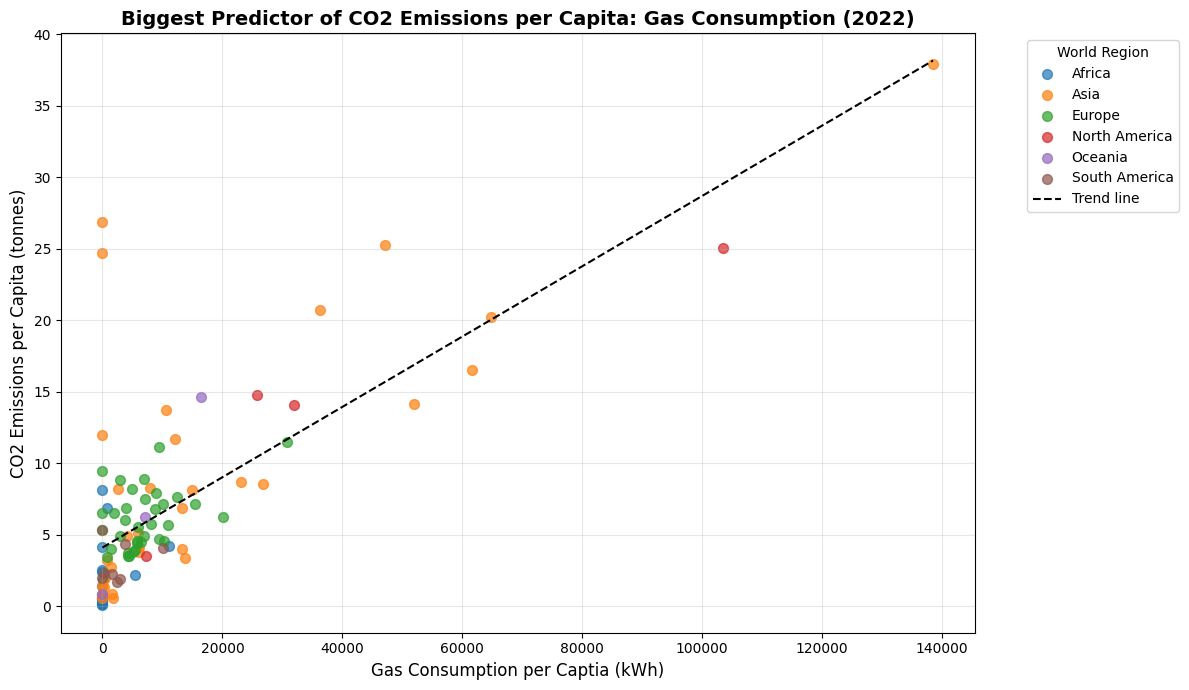

In [23]:
# visualizing in a graph

# data to use
df_matrix_plot = df_year[['Entity', 'Gas', 'CO2_Em', 'World Region']].copy()

# plot figure (scatterplot)

fig, ax = plt.subplots(figsize=(12, 7))

for region, group in df_matrix_plot.groupby('World Region'):
  ax.scatter(group['Gas'], group['CO2_Em'], label=region, alpha=0.7, s=50)

# add extra visualization for extra clearness --> Trendline

z = np.polyfit(df_matrix_plot['Gas'], df_matrix_plot['CO2_Em'], 1)
p = np.poly1d(z)
x_line = np.linspace(df_matrix_plot['Gas'].min(), df_matrix_plot['Gas'].max(), 100)
ax.plot(x_line, p(x_line), color='black', linestyle='--', linewidth=1.5, label='Trend line')

# Labels

ax.set_title('Biggest Predictor of CO2 Emissions per Capita: Gas Consumption (2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Gas Consumption per Captia (kWh)', fontsize=12)
ax.set_ylabel('CO2 Emissions per Capita (tonnes)', fontsize=12)
ax.legend(title='World Region', bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [24]:
# to measure if consitency is true that Gas, GPD_pc and Oil in the last years
# between 2007 and 2022

Em_over_years = range(2007, 2023)

correlations = []

for year in Em_over_years:
  df_year_loop = df_em_4[df_em_4['Year'] == year].copy()
  corr = df_year_loop[['CO2_Em', 'Gas', 'GDP_pc', 'Oil', 'Renewables']].corr()['CO2_Em']
  corr['Year'] = year
  correlations.append(corr)

df_correlations = pd.DataFrame(correlations).set_index('Year')
print(df_correlations)

        CO2_Em       Gas    GDP_pc       Oil  Renewables
Year                                                    
2007.0     1.0  0.787302  0.743903  0.598239   -0.367448
2008.0     1.0  0.761926  0.743909  0.598279   -0.375741
2009.0     1.0  0.778509  0.729627  0.585743   -0.375900
2010.0     1.0  0.790709  0.731925  0.570634   -0.393648
2011.0     1.0  0.797260  0.735983  0.557688   -0.383293
2012.0     1.0  0.808584  0.728958  0.559775   -0.379034
2013.0     1.0  0.800135  0.709527  0.567361   -0.388351
2014.0     1.0  0.790677  0.690292  0.543575   -0.376615
2015.0     1.0  0.793170  0.671822  0.570107   -0.356745
2016.0     1.0  0.772148  0.667930  0.564835   -0.337463
2017.0     1.0  0.764635  0.643148  0.514204   -0.339342
2018.0     1.0  0.754348  0.631455  0.509309   -0.346170
2019.0     1.0  0.745540  0.612119  0.507137   -0.340856
2020.0     1.0  0.742618  0.594984  0.466862   -0.344201
2021.0     1.0  0.761203  0.586507  0.493325   -0.355691
2022.0     1.0  0.757911  0.546

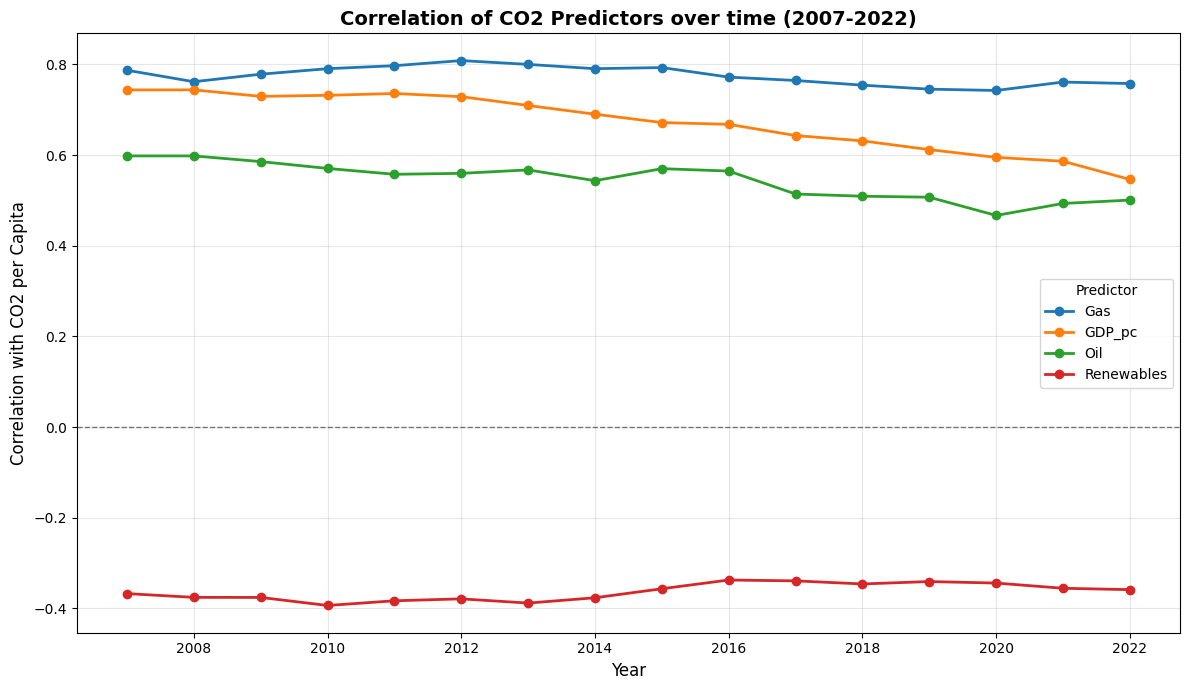

In [25]:
# visualizing plot --> line chart

df_correlations.index = df_correlations.index.astype(int)

# Plot
fig, ax = plt.subplots(figsize=(12, 7))

for col in ('Gas', 'GDP_pc', 'Oil', 'Renewables'):
  ax.plot(df_correlations.index, df_correlations[col], marker='o', linewidth=2, label=col)

ax.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

ax.set_title('Correlation of CO2 Predictors over time (2007-2022)', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Correlation with CO2 per Capita', fontsize=12)
ax.legend(title='Predictor', fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
# Check average CO2 and Renewables in the last 10 years
df_trend = df_em_4.groupby('Year')[['CO2_Em', 'Renewables']].mean().copy()
df_trend = df_trend[(df_trend.index >= 2007) & (df_trend.index <= 2024)].copy()
print(df_trend)


        CO2_Em  Renewables
Year                      
2007  7.771390   25.050397
2008  7.730322   25.531760
2009  7.295126   26.191591
2010  7.570037   26.942395
2011  7.555737   26.362300
2012  7.582511   26.978428
2013  7.347516   28.389268
2014  7.145542   28.539052
2015  7.012095   28.567152
2016  6.921196   28.715815
2017  6.997929   29.435611
2018  6.982281   30.477889
2019  6.913931   30.861542
2020  6.440623   32.403650
2021  6.644931   33.014074
2022  6.669951   33.409207
2023  6.783148   36.221120
2024  6.834409   38.389997


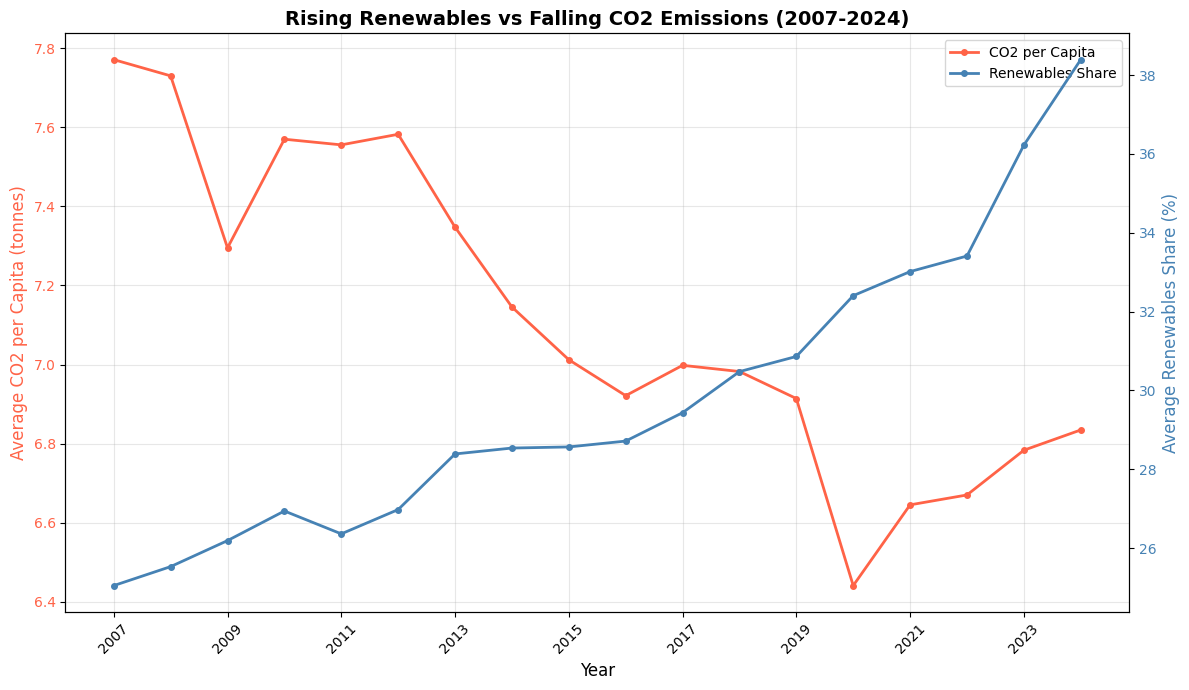

In [27]:
fig, ax1 = plt.subplots(figsize=(12, 7))

ax1.plot(df_trend.index, df_trend['CO2_Em'],
         color='tomato', marker='o', linewidth=2, markersize=4, label='CO2 per Capita')
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Average CO2 per Capita (tonnes)', fontsize=12, color='tomato')
ax1.tick_params(axis='y', labelcolor='tomato')

ax2 = ax1.twinx()
ax2.plot(df_trend.index, df_trend['Renewables'],
         color='steelblue', marker='o', linewidth=2, markersize=4, label='Renewables Share')
ax2.set_ylabel('Average Renewables Share (%)', fontsize=12, color='steelblue')
ax2.tick_params(axis='y', labelcolor='steelblue')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right', fontsize=10)

ax1.set_title('Rising Renewables vs Falling CO2 Emissions (2007-2024)',
              fontsize=14, fontweight='bold')
ax1.set_xticks(df_trend.index[::2])  # show every 2 years to avoid crowding
ax1.tick_params(axis='x', rotation=45)
ax1.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Conclusion Question 1:What is the biggest predictor of a large CO2 output per capita of a country?**

**Conclusion:**
Based on the correlation analysis of 2007–2022 data across all countries, Gas consumption per capita is the strongest predictor of CO2 emissions per capita (CO2 per person), with a correlation of 0.74–0.80 consistently across all years analyzed.

**Key findings:**

**Three important conclusions can be drawn:**

***Gas is the dominant driver***
Countries with high gas consumption per person consistently show the highest CO2 emissions per person. This is particularly visible in wealthy Middle Eastern and European countries.

***Wealthy countries are decoupling from emissions***
GDP per capita dropped from 0.74 in 2007 to 0.55 in 2022 as a predictor. This means that getting richer no longer automatically means emitting more CO2 per person, energy efficiency improvements and the renewable energy transition are breaking this link.

***Renewables are a consistent protective factor.***
The stable negative correlation of -0.36 shows that countries with a higher share of renewable energy consistently emit less CO2 per person, and as the second graph shows, the global average renewable share has grown from 25% to 33% between 2007 and 2022 while average CO2 per person has dropped from 7.8 to 6.7 tonnes.

***2020 is a notable outlier***
The sharp drop in CO2 per person in 2020 was caused by the COVID-19 pandemic, which grounded flights, shut factories and kept cars parked globally. CO2 rebounded in 2021-2022 as economies reopened, confirming this was a temporary disruption rather than a structural change.